# Clase 2 · Variables aleatorias continuas
### Cuando contar ya no alcanza

**Estadística Descriptiva e Inferencial** · Módulo 1 · Sesión 2 de 14

---

En la Clase 1 contamos: cuántos fraudes en 1 000 transacciones, cuántas alertas por día, cuántos intentos hasta la primera venta. Hoy pasamos a lo que se **mide**: cuánto tiempo, cuánto monto, cuánto dura.

### Qué vas a poder hacer al terminar

1. Construir una densidad a partir de datos y explicar por qué el eje Y no es una probabilidad.
2. Responder preguntas de negocio con `.cdf()` y `.ppf()` sin integrar nada a mano.
3. Generar números aleatorios de cualquier distribución a partir de una uniforme.
4. Ajustar dos modelos a los mismos datos y **argumentar** cuál usarías.

### Cómo trabajar este notebook

- Las celdas marcadas **`Guiado`** están completas: léelas, ejecútalas y mira el resultado.
- Las celdas marcadas **`Ejercicio`** tienen `TODO`. Ahí trabajas tú.
- Cada ejercicio termina con una celda de verificación que te dice si el número está bien.
- La semilla es **42**. Si tus números no coinciden con los míos, revisa eso antes que nada.

> ⚠️ Ejecuta la celda de setup completa antes de tocar cualquier otra cosa.

---
## Setup

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# La semilla del curso. Misma que en las slides y en la solución.
SEED = 42
rng = np.random.default_rng(SEED)

# El caso de la clase: días entre alertas AML de un equipo de monitoreo.
MEDIA_DIAS = 30            # tiempo medio observado entre alertas
LAM = 1 / MEDIA_DIAS       # tasa lambda de la exponencial

# Paleta del curso (para que los gráficos se vean como las slides)
AZUL, MAGENTA, GRIS, CLARO = "#2D6CDF", "#E23C8A", "#6B7C99", "#DCE3F0"
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": "#1B2A44",
    "axes.grid": True, "grid.color": CLARO, "grid.linewidth": 0.8,
    "xtick.color": GRIS, "ytick.color": GRIS, "font.size": 10,
})

print(f"numpy {np.__version__} · scipy {stats.__name__} listo")
print(f"Caso: tiempo medio entre alertas = {MEDIA_DIAS} días  →  lambda = {LAM:.5f} por día")

numpy 2.5.1 · scipy scipy.stats listo
Caso: tiempo medio entre alertas = 30 días  →  lambda = 0.03333 por día


---
# Bloque 0 · Los datos

Simulamos 2 000 esperas entre alertas consecutivas. En tu trabajo esto sería una consulta
a la base de monitoreo; aquí lo generamos para que todos tengamos exactamente los mismos números.

In [2]:
# ── Guiado ────────────────────────────────────────────────────────────────
n = 2000
espera = rng.exponential(scale=MEDIA_DIAS, size=n)   # días entre alertas

df = pd.DataFrame({"dias_entre_alertas": espera})
print(df.describe().round(2))

print("\n--- Los dos números que importan hoy ---")
print(f"Media observada .......... {espera.mean():7.2f} días")
print(f"Percentil 95 observado ... {np.percentile(espera, 95):7.2f} días")
print(f"Ratio p95 / media ........ {np.percentile(espera, 95) / espera.mean():7.2f}")

       dias_entre_alertas
count             2000.00
mean                30.45
std                 30.81
min                  0.00
25%                  9.12
50%                 20.90
75%                 41.73
max                228.44

--- Los dos números que importan hoy ---
Media observada ..........   30.45 días
Percentil 95 observado ...   92.62 días
Ratio p95 / media ........    3.04


**Antes de seguir, mira ese ratio.** El percentil 95 es casi tres veces la media.
Toda la Clase 2 existe por esa distancia: si dimensionas con el promedio, te quedas corto
justo en los casos que te rompen la operación.

---
# Bloque 1 · Densidad a mano  <sub>15 min</sub>

Reproducimos la slide 6: el mismo dato con bins gruesos y con bins finos.
La pregunta que quiero que respondas al final del bloque es **por qué el eje Y deja de moverse**
cuando el eje Y es densidad y no frecuencia.

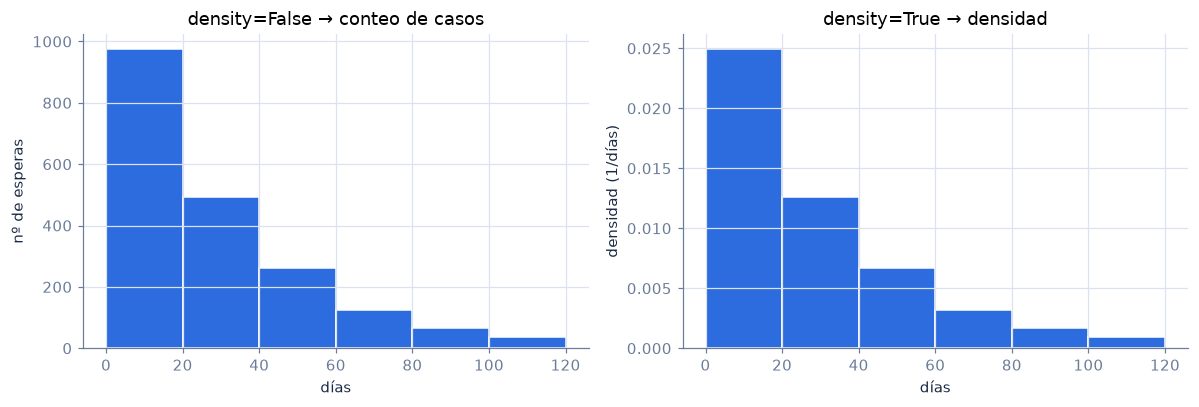

Mismo histograma, misma forma. Lo único que cambia es la escala del eje Y.


In [3]:
# ── Guiado ────────────────────────────────────────────────────────────────
# Dos formas de graficar el MISMO dato. Fíjate solo en el eje Y.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(espera, bins=6, range=(0, 120), color=AZUL, edgecolor="white")
axes[0].set_title("density=False → conteo de casos")
axes[0].set_xlabel("días");  axes[0].set_ylabel("nº de esperas")

axes[1].hist(espera, bins=6, range=(0, 120), density=True, color=AZUL, edgecolor="white")
axes[1].set_title("density=True → densidad")
axes[1].set_xlabel("días");  axes[1].set_ylabel("densidad (1/días)")

plt.tight_layout(); plt.show()

print("Mismo histograma, misma forma. Lo único que cambia es la escala del eje Y.")

### Qué hace `density=True`

Para cada barra:

$$\text{altura} = \frac{\text{casos en el bin}}{n \times \text{ancho del bin}}$$

Dividir entre el ancho es el paso clave. Si partes un bin en dos, los casos se reparten a la
mitad **y** el ancho se reparte a la mitad: la altura se queda donde estaba. Esa estabilidad
es lo que permite que exista una curva límite, y esa curva es $f(x)$.

> **Detalle práctico:** cuando pasas `range=(0, 120)`, matplotlib y numpy normalizan usando
> los casos que caen **dentro** de ese rango, no los 2 000 originales. Aquí se nos queda fuera
> un puñado de esperas larguísimas, así que el $n$ de la fórmula es el de los datos en rango.
> Es exactamente el tipo de detalle que descuadra un gráfico en producción.

In [4]:
# ── Solución 1.1 ──────────────────────────────────────────────────────────
ancho = 20
casos_primer_bin = ((espera >= 0) & (espera < ancho)).sum()
n_rango = ((espera >= 0) & (espera < 120)).sum()

altura_manual = casos_primer_bin / (n_rango * ancho)

print(f"Casos en el primer bin: {casos_primer_bin}  ·  casos en el rango 0-120: {n_rango}")
print(f"Altura calculada a mano: {altura_manual:.5f}")
print(f"Si dividieras entre los {n} datos totales daría {casos_primer_bin/(n*ancho):.5f}: parecido, pero no igual.")

Casos en el primer bin: 975  ·  casos en el rango 0-120: 1955
Altura calculada a mano: 0.02494
Si dividieras entre los 2000 datos totales daría 0.02438: parecido, pero no igual.


In [5]:
# ── Verificación 1.1 ──────────────────────────────────────────────────────
alturas, bordes = np.histogram(espera, bins=6, range=(0, 120), density=True)
print(f"Lo que devuelve numpy: {alturas[0]:.5f}")
if altura_manual is not None and np.isclose(altura_manual, alturas[0]):
    print("✅ Coinciden. density=True no es magia: es una división.")
else:
    print("❌ Todavía no. Revisa que estés dividiendo entre n Y entre el ancho.")

Lo que devuelve numpy: 0.02494
✅ Coinciden. density=True no es magia: es una división.


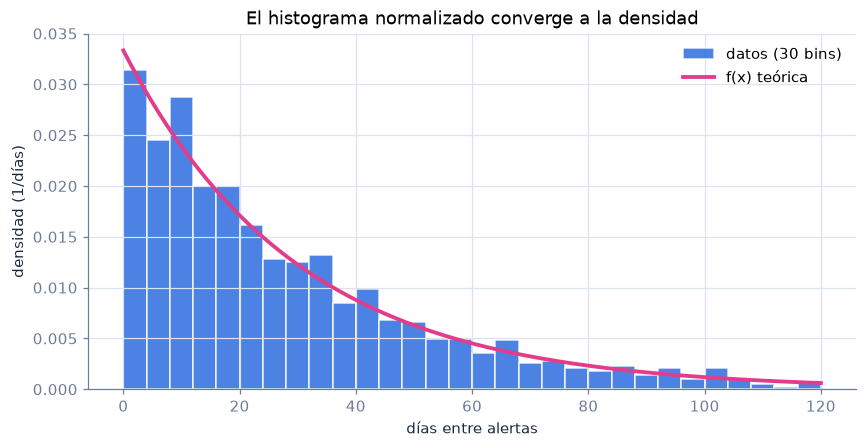

f(0) = 0.03333  ·  vale 1/30, no 'una probabilidad'


In [6]:
# ── Solución 1.2 ──────────────────────────────────────────────────────────
x = np.linspace(0, 120, 400)

f_teorica = stats.expon.pdf(x, scale=MEDIA_DIAS)      # equivale a LAM * np.exp(-LAM * x)

plt.hist(espera, bins=30, range=(0, 120), density=True,
         color=AZUL, edgecolor="white", alpha=0.85, label="datos (30 bins)")
plt.plot(x, f_teorica, color=MAGENTA, lw=2.5, label="f(x) teórica")
plt.xlabel("días entre alertas"); plt.ylabel("densidad (1/días)")
plt.title("El histograma normalizado converge a la densidad")
plt.legend(frameon=False); plt.show()

print(f"f(0) = {stats.expon.pdf(0, scale=MEDIA_DIAS):.5f}  ·  vale 1/30, no 'una probabilidad'")

In [7]:
# ── Solución 1.3 ──────────────────────────────────────────────────────────
for nb in [6, 12, 30, 60]:
    alturas_nb, bordes_nb = np.histogram(espera, bins=nb, range=(0, 120), density=True)
    idx = np.searchsorted(bordes_nb, 2, side="right") - 1   # bin que contiene el día 2
    altura_en_2 = alturas_nb[idx]
    print(f"{nb:3d} bins → altura cerca de x=2: {altura_en_2:.5f}")

print(f"\nf(2) teórica = {stats.expon.pdf(2, scale=MEDIA_DIAS):.5f}")
print("La altura NO se aplasta al afinar los bins: converge. Con frecuencias absolutas sí se aplastaría.")

  6 bins → altura cerca de x=2: 0.02494
 12 bins → altura cerca de x=2: 0.02813
 30 bins → altura cerca de x=2: 0.03146
 60 bins → altura cerca de x=2: 0.03453

f(2) teórica = 0.03118
La altura NO se aplasta al afinar los bins: converge. Con frecuencias absolutas sí se aplastaría.


---
# Bloque 2 · CDF y cuantiles  <sub>15 min</sub>

Aquí está el 80 % de lo que vas a usar en el trabajo. Dos métodos:

| Método | Pregunta que responde | Entra | Sale |
|---|---|---|---|
| `.cdf(x)` | ¿qué probabilidad hay de no pasar de x? | un valor | una probabilidad |
| `.ppf(p)` | ¿hasta qué valor llega el p % de los casos? | una probabilidad | un valor |

Son inversas una de la otra. `.pdf()` casi no aparece: sirve para graficar y para verosimilitud, no para decidir.

In [8]:
# ── Guiado ────────────────────────────────────────────────────────────────
# Congelamos la distribución una vez y la reutilizamos.
dist = stats.expon(scale=MEDIA_DIAS)

# Reproducimos la tabla de la slide 9
niveles = [0.50, 0.80, 0.95, 0.99, 0.999]
tabla = pd.DataFrame({
    "nivel_p": [f"{p:.1%}" for p in niveles],
    "cuantil_teorico_dias": [round(dist.ppf(p), 1) for p in niveles],
    "cuantil_observado_dias": [round(np.quantile(espera, p), 1) for p in niveles],
})
print(tabla.to_string(index=False))

print(f"\nMedia = {MEDIA_DIAS} días  ·  p95 = {dist.ppf(0.95):.1f} días  →  ratio {dist.ppf(0.95)/MEDIA_DIAS:.2f}")
print("Del p95 al p99.9 el cuantil se multiplica por más de 2. Ahí vive el riesgo.")

nivel_p  cuantil_teorico_dias  cuantil_observado_dias
  50.0%                  20.8                    20.9
  80.0%                  48.3                    48.1
  95.0%                  89.9                    92.6
  99.0%                 138.2                   139.5
  99.9%                 207.2                   221.6

Media = 30 días  ·  p95 = 89.9 días  →  ratio 3.00
Del p95 al p99.9 el cuantil se multiplica por más de 2. Ahí vive el riesgo.


### Las cinco preguntas de negocio

El equipo de monitoreo AML te pregunta lo siguiente. Responde cada una con **una sola línea**
usando `dist.cdf()` o `dist.ppf()`.

In [9]:
# ── Solución 2.1 ──────────────────────────────────────────────────────────
p1 = dist.cdf(7)                     # 0.2081
p2 = dist.sf(60)                     # 1 - cdf(60) = 0.1353
p3 = dist.cdf(45) - dist.cdf(15)     # 0.3834
d4 = dist.ppf(0.95)                  # 89.87 días
p5 = dist.cdf(MEDIA_DIAS)            # 0.6321

print(f"1. P(espera < 7 días) ................ {p1:.4f}  ({p1:.1%})")
print(f"2. P(espera > 60 días) .............. {p2:.4f}  ({p2:.1%})")
print(f"3. P(15 < espera < 45 días) ......... {p3:.4f}  ({p3:.1%})")
print(f"4. El 5 % más lento empieza en ...... {d4:.1f} días")
print(f"5. Proporción por debajo de la media  {p5:.4f}  ({p5:.1%})")

1. P(espera < 7 días) ................ 0.2081  (20.8%)
2. P(espera > 60 días) .............. 0.1353  (13.5%)
3. P(15 < espera < 45 días) ......... 0.3834  (38.3%)
4. El 5 % más lento empieza en ...... 89.9 días
5. Proporción por debajo de la media  0.6321  (63.2%)


In [10]:
# ── Verificación 2.1 ──────────────────────────────────────────────────────
esperados = {"p1": 0.20811, "p2": 0.13534, "p3": 0.38340, "d4": 89.8720, "p5": 0.63212}
obtenidos = {"p1": p1, "p2": p2, "p3": p3, "d4": d4, "p5": p5}
for k, v_ok in esperados.items():
    v = obtenidos[k]
    if v is None:
        print(f"⬜ {k}: sin responder")
    elif np.isclose(v, v_ok, rtol=1e-3):
        print(f"✅ {k} = {v:.5f}")
    else:
        print(f"❌ {k} = {v:.5f} · esperado {v_ok:.5f}")

✅ p1 = 0.20811
✅ p2 = 0.13534
✅ p3 = 0.38340
✅ d4 = 89.87197
✅ p5 = 0.63212


### La pregunta 5 merece una pausa

El **63 %** de las esperas es menor que la media. No es un error de cálculo: en una distribución
asimétrica la media no parte la muestra en dos, la parte el **mediano** (que aquí vale
20.8 días, no 30). Cada vez que alguien dice *"en promedio tardamos 30 días"* está describiendo
un valor que la mayoría de los casos no alcanza.

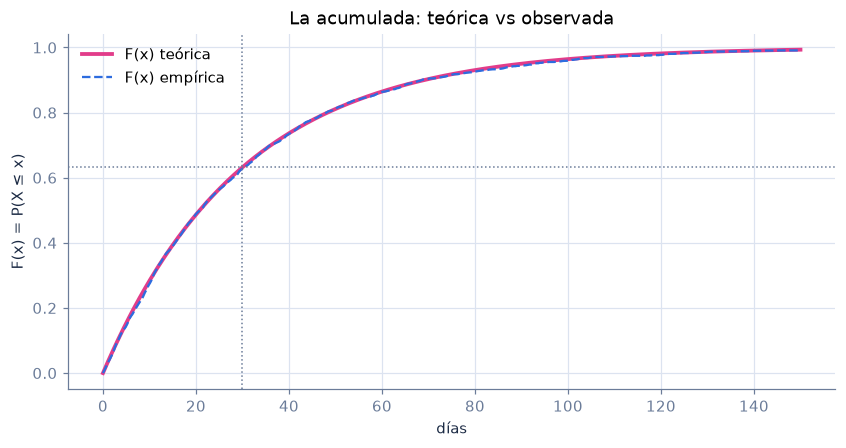

Las dos curvas casi se tapan: con n=2000 la empírica ya es un buen estimador de la teórica.


In [11]:
# ── Solución 2.2 ──────────────────────────────────────────────────────────
x = np.linspace(0, 150, 400)
orden = np.sort(espera)

cdf_teorica  = dist.cdf(x)
cdf_empirica = np.searchsorted(orden, x, side="right") / n

plt.plot(x, cdf_teorica, color=MAGENTA, lw=2.5, label="F(x) teórica")
plt.plot(x, cdf_empirica, color=AZUL, lw=1.5, ls="--", label="F(x) empírica")
plt.axvline(MEDIA_DIAS, color=GRIS, ls=":", lw=1)
plt.axhline(0.6321, color=GRIS, ls=":", lw=1)
plt.xlabel("días"); plt.ylabel("F(x) = P(X ≤ x)")
plt.title("La acumulada: teórica vs observada")
plt.legend(frameon=False); plt.show()

print("Las dos curvas casi se tapan: con n=2000 la empírica ya es un buen estimador de la teórica.")

---
# Bloque 3 · Inverse transform sampling  <sub>20 min</sub>

`rng.exponential()` existe, pero hoy no lo usamos. Vas a construir esperas exponenciales
**solo con números uniformes**, que es lo que hace cualquier simulador por dentro.

### La idea en una línea

Si $U \sim \text{Uniforme}(0,1)$ y $F$ es la acumulada de la distribución que quieres,
entonces $X = F^{-1}(U)$ tiene exactamente esa distribución.

Para la exponencial se despeja a mano:

$$u = 1 - e^{-\lambda x} \;\Longrightarrow\; x = -\frac{\ln(1-u)}{\lambda}$$

Piénsalo como leer la CDF al revés: entras por el eje Y con un número al azar entre 0 y 1,
y sales por el eje X con un valor de la distribución. Donde la curva es empinada
(esperas cortas) cae mucha probabilidad, y por eso salen muchos valores pequeños.

In [12]:
# ── Solución 3.1 ──────────────────────────────────────────────────────────
rng_it = np.random.default_rng(SEED)
u = rng_it.random(n)

espera_it = -np.log(1 - u) / LAM

print(f"Primeros 5 valores: {np.round(espera_it[:5], 2)}")
print(f"Media generada: {espera_it.mean():.2f} días  (esperado ≈ {MEDIA_DIAS})")

Primeros 5 valores: [44.61 17.33 58.68 35.86  2.97]
Media generada: 30.56 días  (esperado ≈ 30)


Prueba KS contra Exp(30): estadístico 0.0176 · p-valor 0.557
✅ No hay evidencia de que tus datos NO sean exponenciales. El método funciona.


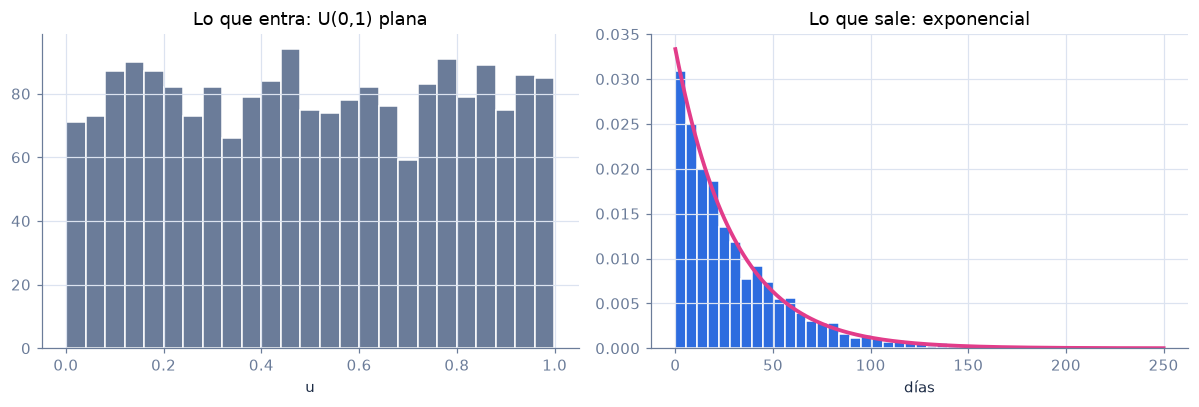

In [13]:
# ── Verificación 3.1 ──────────────────────────────────────────────────────
if espera_it is None:
    print("⬜ Sin responder")
else:
    ks = stats.kstest(espera_it, "expon", args=(0, MEDIA_DIAS))
    print(f"Prueba KS contra Exp(30): estadístico {ks.statistic:.4f} · p-valor {ks.pvalue:.3f}")
    if ks.pvalue > 0.05:
        print("✅ No hay evidencia de que tus datos NO sean exponenciales. El método funciona.")
    else:
        print("❌ Algo está mal en la transformación. Revisa el signo y el 1-u.")

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    axes[0].hist(u, bins=25, color=GRIS, edgecolor="white")
    axes[0].set_title("Lo que entra: U(0,1) plana"); axes[0].set_xlabel("u")
    axes[1].hist(espera_it, bins=40, density=True, color=AZUL, edgecolor="white")
    axes[1].plot(np.linspace(0, 250, 300), dist.pdf(np.linspace(0, 250, 300)),
                 color=MAGENTA, lw=2.5)
    axes[1].set_title("Lo que sale: exponencial"); axes[1].set_xlabel("días")
    plt.tight_layout(); plt.show()

### Por qué esto importa más de lo que parece

Todo el bloque de A/B testing del Módulo 3 se apoya en simulación: para estimar la potencia de
un experimento generas miles de escenarios y cuentas en cuántos detectas el efecto. Si sabes
transformar uniformes, puedes simular **cualquier** proceso de negocio, no solo los que traen
función hecha en scipy.

In [14]:
# ── Solución 3.2 ──────────────────────────────────────────────────────────
forma, escala = 1.8, 36.0
u2 = np.random.default_rng(SEED + 1).random(n)

vida_it = escala * (-np.log(1 - u2)) ** (1 / forma)

print(f"Media generada .......... {vida_it.mean():.2f} meses")
print(f"Media teórica ........... {stats.weibull_min.mean(forma, scale=escala):.2f} meses")
print("Con forma > 1 el riesgo crece con la edad: la exponencial no puede representar esto.")

Media generada .......... 32.41 meses
Media teórica ........... 32.01 meses
Con forma > 1 el riesgo crece con la edad: la exponencial no puede representar esto.


---
# Bloque 4 · Ajuste y decisión  <sub>20 min</sub>

Ahora el ejercicio que se parece a tu trabajo. Te entrego los **meses hasta el default** de una
cartera de créditos de consumo. No te digo de dónde salen. Tienes que decidir con qué
distribución los modelas y **defender la decisión**.

No hay una respuesta única. Se evalúa el argumento, no el número.

n = 1500  ·  media 32.1 meses  ·  mediana 29.0 meses
p95 = 65.6 meses


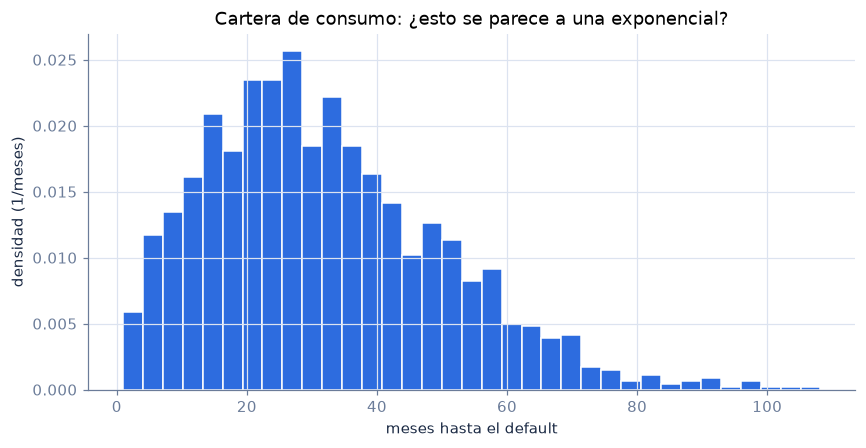

Primera pista visual: la exponencial es máxima en x=0 y solo baja.
Este histograma sube, hace pico y luego baja. Guarda esa observación.


In [15]:
# ── Guiado ────────────────────────────────────────────────────────────────
# La cartera: 1500 créditos que terminaron en default, con el mes en que ocurrió.
vida = np.random.default_rng(7).weibull(1.8, 1500) * 36.0

print(f"n = {len(vida)}  ·  media {vida.mean():.1f} meses  ·  mediana {np.median(vida):.1f} meses")
print(f"p95 = {np.percentile(vida, 95):.1f} meses")

plt.hist(vida, bins=35, density=True, color=AZUL, edgecolor="white")
plt.xlabel("meses hasta el default"); plt.ylabel("densidad (1/meses)")
plt.title("Cartera de consumo: ¿esto se parece a una exponencial?")
plt.show()

print("Primera pista visual: la exponencial es máxima en x=0 y solo baja.")
print("Este histograma sube, hace pico y luego baja. Guarda esa observación.")

In [16]:
# ── Solución 4.1 ──────────────────────────────────────────────────────────
par_exp = stats.expon.fit(vida, floc=0)
par_wei = stats.weibull_min.fit(vida, floc=0)

logL_exp = stats.expon.logpdf(vida, *par_exp).sum()
logL_wei = stats.weibull_min.logpdf(vida, *par_wei).sum()

aic_exp = 2 * 1 - 2 * logL_exp
aic_wei = 2 * 2 - 2 * logL_wei

print(f"Exponencial → escala {par_exp[1]:.2f} · logL {logL_exp:.1f} · AIC {aic_exp:.1f}")
print(f"Weibull ..... → forma {par_wei[0]:.2f}, escala {par_wei[2]:.2f} · logL {logL_wei:.1f} · AIC {aic_wei:.1f}")
print(f"\nDiferencia de AIC: {aic_exp - aic_wei:.1f} a favor de Weibull.")
print("La forma estimada ronda 1.8: claramente mayor que 1, o sea riesgo creciente con la edad.")
print("Si la forma hubiera salido cerca de 1, la Weibull se reduciría a la exponencial y")
print("preferiríamos la exponencial por ser más simple.")

Exponencial → escala 32.07 · logL -6701.7 · AIC 13405.3
Weibull ..... → forma 1.82, escala 36.07 · logL -6369.5 · AIC 12743.1

Diferencia de AIC: 662.2 a favor de Weibull.
La forma estimada ronda 1.8: claramente mayor que 1, o sea riesgo creciente con la edad.
Si la forma hubiera salido cerca de 1, la Weibull se reduciría a la exponencial y
preferiríamos la exponencial por ser más simple.


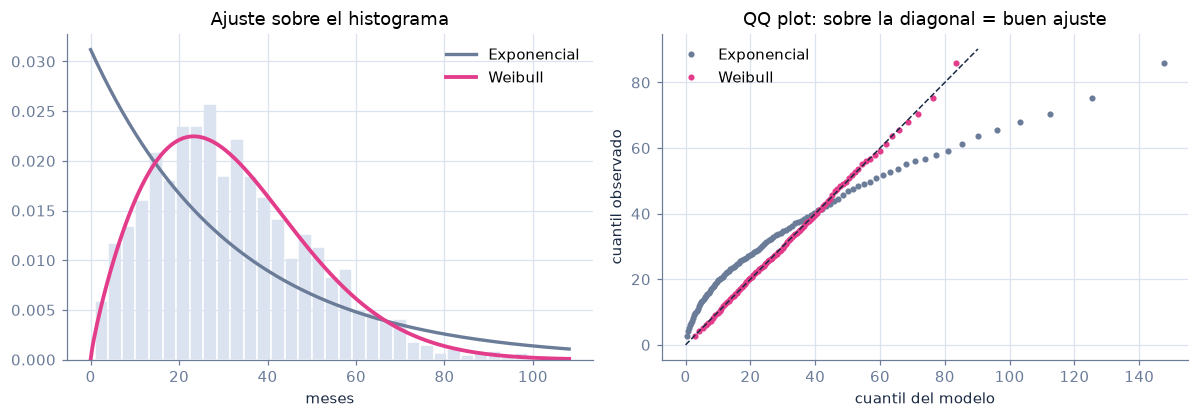

In [17]:
# ── Guiado: la evidencia visual ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))

xs = np.linspace(0, vida.max(), 300)
axes[0].hist(vida, bins=35, density=True, color=CLARO, edgecolor="white")
axes[0].plot(xs, stats.expon.pdf(xs, *par_exp), color=GRIS, lw=2.2, label="Exponencial")
axes[0].plot(xs, stats.weibull_min.pdf(xs, *par_wei), color=MAGENTA, lw=2.5, label="Weibull")
axes[0].set_title("Ajuste sobre el histograma"); axes[0].set_xlabel("meses")
axes[0].legend(frameon=False)

# QQ plot: cuantiles observados vs cuantiles de cada modelo
p = np.linspace(0.01, 0.99, 99)
q_obs = np.quantile(vida, p)
axes[1].plot(stats.expon.ppf(p, *par_exp), q_obs, "o", ms=3, color=GRIS, label="Exponencial")
axes[1].plot(stats.weibull_min.ppf(p, *par_wei), q_obs, "o", ms=3, color=MAGENTA, label="Weibull")
lim = [0, max(q_obs) * 1.05]
axes[1].plot(lim, lim, ls="--", lw=1, color="#1B2A44")
axes[1].set_title("QQ plot: sobre la diagonal = buen ajuste")
axes[1].set_xlabel("cuantil del modelo"); axes[1].set_ylabel("cuantil observado")
axes[1].legend(frameon=False)

plt.tight_layout(); plt.show()

In [18]:
# ── Solución 4.2 ──────────────────────────────────────────────────────────
s_exp = stats.expon.sf(24, *par_exp)
s_wei = stats.weibull_min.sf(24, *par_wei)
s_obs = (vida > 24).mean()

print(f"Exponencial dice: {s_exp:.1%} de la cartera sobrevive 24 meses")
print(f"Weibull dice ...: {s_wei:.1%}")
print(f"Observado real .: {s_obs:.1%}   ← el juez de la discusión")
print(f"\nDiferencia entre modelos: {abs(s_exp - s_wei):.1%}")
print(f"Sobre 100 000 créditos son {abs(s_exp - s_wei) * 100000:,.0f} créditos mal clasificados.")
print("\nLa exponencial sobreestima la supervivencia en el mediano plazo porque no")
print("puede representar que el riesgo se acumula con la antigüedad.")

Exponencial dice: 47.3% de la cartera sobrevive 24 meses
Weibull dice ...: 62.1%
Observado real .: 62.7%   ← el juez de la discusión

Diferencia entre modelos: 14.8%
Sobre 100 000 créditos son 14,820 créditos mal clasificados.

La exponencial sobreestima la supervivencia en el mediano plazo porque no
puede representar que el riesgo se acumula con la antigüedad.


### Ejercicio 4.3 · La parte que no es código

Escribe tu respuesta en la celda de abajo, en tres o cuatro líneas. Tiene que responder:

1. **Qué distribución eliges** y con qué evidencia (AIC, QQ plot, forma estimada, histograma).
2. **Qué supuesto de la exponencial se viola** en estos datos, en palabras de negocio.
3. **Qué decisión concreta cambia** si eliges mal: nombra el número que se mueve.

Un criterio que puedes usar: si la forma estimada de la Weibull está cerca de 1,
quédate con la exponencial porque es más simple y más fácil de comunicar. Si está
claramente por encima de 1, el riesgo crece con la edad y la exponencial te va a mentir
justo en el tramo que te interesa.

_Tu respuesta:_

1.
2.
3.

---
# Cierre

### Checklist de la sesión

- [ ] Sé explicar por qué `density=True` divide entre el ancho del bin.
- [ ] Puedo traducir una pregunta de negocio a `.cdf()` o `.ppf()` sin dudar cuál va.
- [ ] Entiendo por qué el 63 % de las esperas queda por debajo de la media.
- [ ] Puedo generar cualquier distribución a partir de uniformes.
- [ ] Sé qué mirar para decidir entre exponencial y Weibull.

### Reto para la próxima clase

Toma **cualquier serie de tiempos de tu trabajo** (duración de tickets, días entre incidencias,
tiempo de aprobación de un trámite), calcula el p95 y la media, y trae el **ratio entre ambos**.
En la exponencial ese ratio vale exactamente 3.00. Si el tuyo es mucho mayor, tienes cola pesada
y lo vamos a necesitar en el Módulo 2.

### Clase 3

La normal y sus derivadas: por qué aparece en todas partes aunque nadie la haya invitado.

---
_Estadística Descriptiva e Inferencial · Módulo 1 · Clase 2 · SEED = 42_